# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [5]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [7]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://davidson-timber-painting-smaller.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


In [39]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Nguyen Mau Lan"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600400"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [8]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🟢 Util: 11.0% | Mem: 1.3/16.0GB | Power: 26W | Temp: 33°C
   GPU 1 [T4] 🟢 Util: 0.9% | Mem: 0.6/16.0GB | Power: 34W | Temp: 43°C

🖥️  node-01:
   GPU 0 [A100] 🟢 Util: 7.9% | Mem: 1.0/80.0GB | Power: 31W | Temp: 44°C
   GPU 1 [A100] 🟢 Util: 13.7% | Mem: 1.4/80.0GB | Power: 36W | Temp: 34°C

🖥️  node-02:
   GPU 0 [V100] 🟢 Util: 3.4% | Mem: 1.5/32.0GB | Power: 28W | Temp: 30°C
   GPU 1 [V100] 🟢 Util: 1.4% | Mem: 0.5/32.0GB | Power: 33W | Temp: 31°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 7.3% | Mem: 1.0/16.0GB | Power: 47W | Temp: 38°C
   GPU 1 [T4] 🟢 Util: 11.0% | Mem: 0.8/16.0GB | Power: 46W | Temp: 32°C


In [9]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           0
Idle GPUs:           8
Avg Utilization:     7.1%
Memory Used:         8.1 GB
Memory Capacity:     288.0 GB
Total Power Draw:    282 W
Node Count:          4


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [10]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-00', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-01', 'gpu_id': 0}]
   inference-api-003: running → [{'node_id': 'node-00', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-01', 'gpu_id': 1}, {'node_id': 'node-02', 'gpu_id': 0}]

📊 Updated metrics:
   Busy GPUs: 5/8 | Utilization: 47.5%


In [11]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $1.1949
   Total Savings:  $1.2927
   Budget Used:    1.2%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [12]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.1976     43.5    % low
A100       $3.67       $2.4290     33.8    % medium
V100       $2.48       $1.3837     44.2    % high


In [13]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [14]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 2

   ⚠️  Preempted:
      - spot-t4-001 (ran for 2s, 60s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0004
   On-demand equiv:  $0.0015
   Total saved:      $0.0010 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [15]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 80.0
   scale_down_threshold: 20.0
   cooldown_seconds: 60
   max_nodes: 8
   min_nodes: 1
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [16]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 47.5% within thresholds [25.0-70.0%]
   Current utilization: 47.5%
   Nodes: 4 → 4

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 47.5% | Nodes: 4→4
   Cycle 2: no_action    | Util: 47.5% | Nodes: 4→4
   Cycle 3: no_action    | Util: 47.5% | Nodes: 4→4
   Cycle 4: no_action    | Util: 47.5% | Nodes: 4→4
   Cycle 5: no_action    | Util: 47.5% | Nodes: 4→4


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [17]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 2: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 3: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 4: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 5: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%


In [18]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          23.2%
   Total Idle Cost:        $0.044165
   Total Cost:             $0.190280
   Potential Monthly Save:  $2289.51
   Severity:               LOW


In [19]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [20]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 8 GPUs across 4 nodes
   Utilization: 47.5% | Busy: 5 | Idle: 3

💰 BILLING: $1.1949 / $100.00 budget
   Alert: OK | Savings: $1.2927

🎯 SPOT: Saved $0.0189 (70.0%)

🗑️  WASTE: 23.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

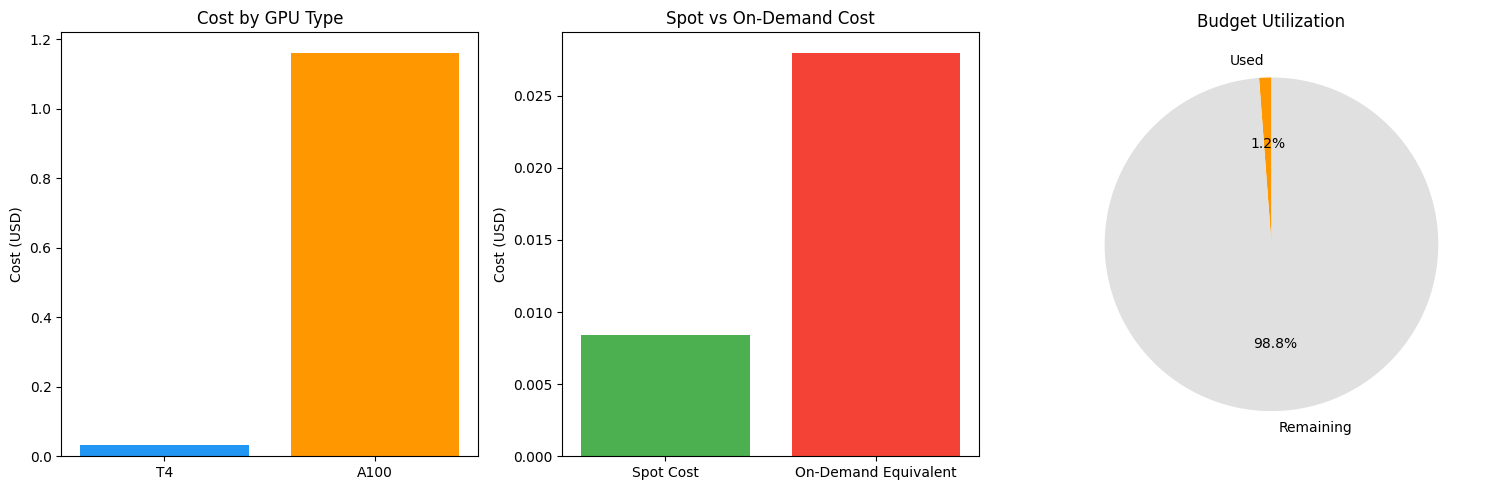

📊 Chart saved as finops_cost_breakdown.png


In [21]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


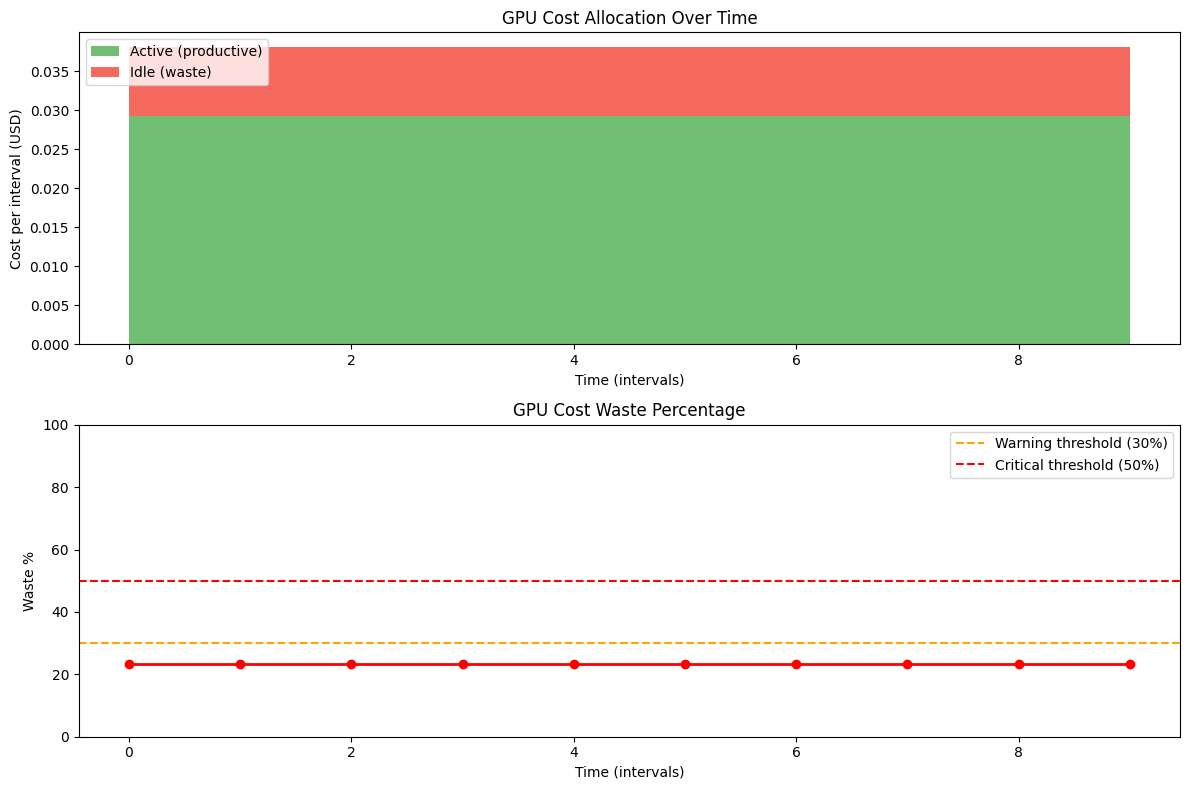

In [22]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [23]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 8 | Util: 47.5% | Idle: 3

2️⃣  Submitting heavy workloads...
   After load: Util: 76.1% | Busy: 8/8

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 76.1% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.040000
   Waste: 4.9%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0362 (70.0%)

7️⃣  Final billing:
   Total spend: $1.3640
   Total saved: $1.4151
   Budget: 1.4% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [24]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [25]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 9.9W
   Temp: 46C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 9.925
   temp_c: 46.0

   Method: pynvml

Ready for training.


In [26]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:02<00:00, 63.1MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [27]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.7167 | Acc: 37.4% | Time: 41.1s | Samples: 40
   Epoch 2/3 | Loss: 1.1600 | Acc: 58.0% | Time: 41.5s | Samples: 40
   Epoch 3/3 | Loss: 0.8881 | Acc: 69.0% | Time: 44.0s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      126.5s
   Peak memory:     0.82 GB
   Avg GPU util:    95.6%
   Avg power:       66.7W
   Avg temperature: 70.8C
   Max GPU util:    99.0%
   Estimated cost:  $0.012302


In [28]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.8968 | Acc: 30.6% | Time: 19.6s | Samples: 40
   Epoch 2/3 | Loss: 1.3351 | Acc: 50.8% | Time: 19.1s | Samples: 40
   Epoch 3/3 | Loss: 1.0366 | Acc: 62.9% | Time: 19.3s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      57.9s
   Peak memory:     0.60 GB
   Avg GPU util:    90.9%
   Avg power:       65.1W
   Avg temperature: 76.3C
   Max GPU util:    94.0%
   Estimated cost:  $0.005633


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                126.5           57.9            2.18x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012302       $0.005633       $0.006669 saved
Cost Saving %             ---             ---             54.2%
Avg GPU Util %            95.6            90.9           
Avg Power (W)             66.7            65.1           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$3.85 -> SAVE $4.55
   1 week training: FP32=$58.80 vs AMP=$26.92 -> SAVE $31.88
   1 month training: FP32=$252.00 vs AMP=$115.39 -> SAVE $136.61


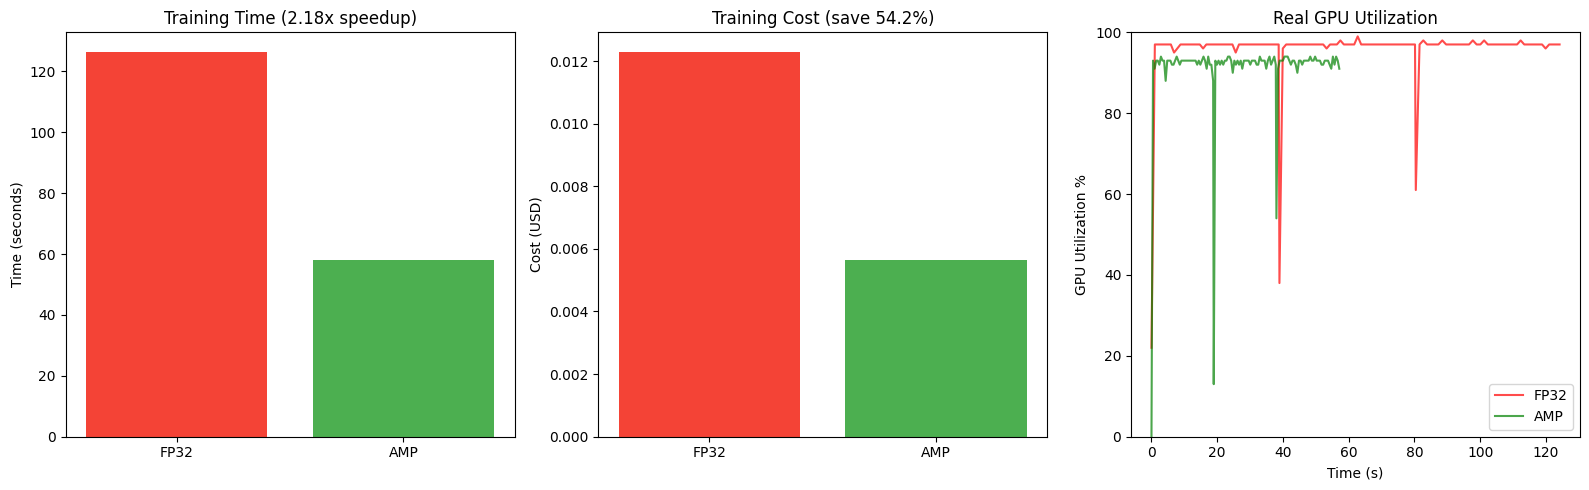

In [29]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012300 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.003900

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.014000
   Total Savings:   $0.003900
   Workloads:       2

   Cost snapshot taken: waste=22.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $1.3640
   Total Savings:        $1.4151
   Budget Utilization:   1.4%
   Alert:                OK


Real GPU Telemetry During Training


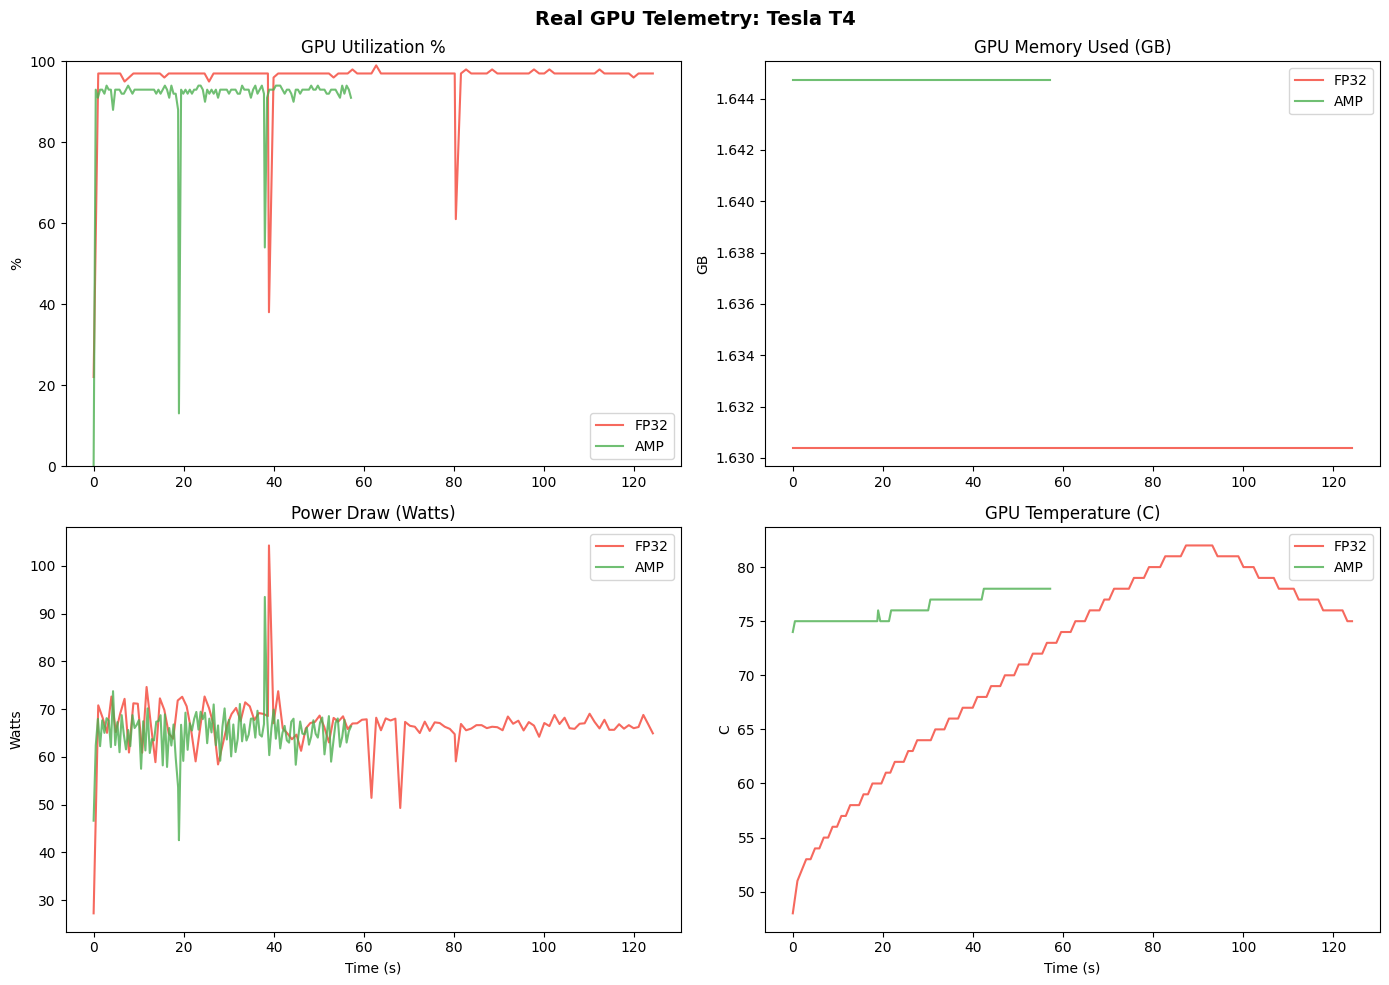

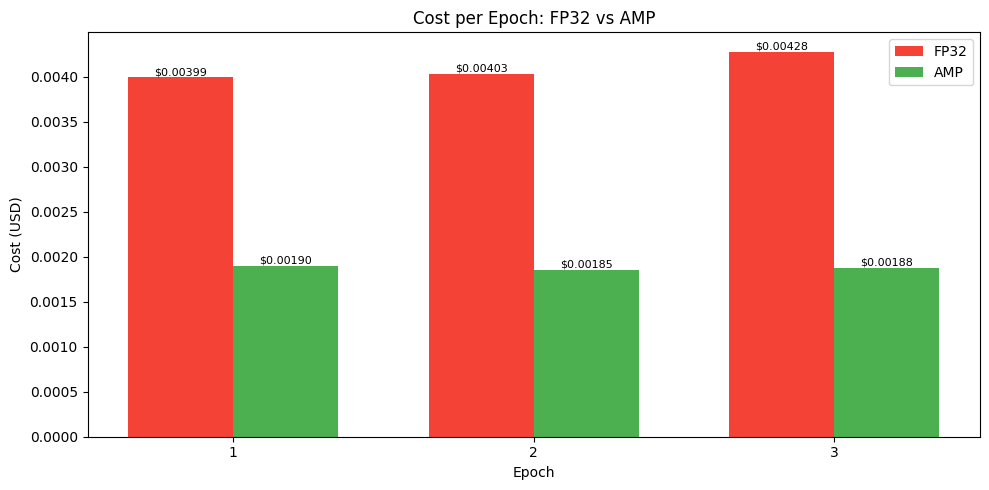


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [31]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

In [40]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Analyze multi-GPU training costs with realistic scaling efficiency.
    
    Parameters:
        base_time_hours (float): Single-GPU training time in hours
        gpu_type (str): GPU type (T4, A100, etc.)
        gpu_counts (list): List of GPU counts to analyze (e.g., [1, 2, 4, 8])
        scaling_factors (dict, optional): Scaling efficiency {gpu_count: speedup_factor}
                                         If None, use realistic sub-linear scaling
    
    Returns:
        dict: Analysis with costs, times, and efficiency metrics
    """
    if gpu_type not in GPU_PRICING:
        gpu_type = "T4"
    
    price_per_hour = GPU_PRICING[gpu_type]
    
    # Default: realistic sub-linear scaling (overhead increases with GPU count)
    default_scaling = {
        1: 1.0,      # baseline
        2: 1.8,      # 80% efficiency
        4: 3.2,      # 80% efficiency per GPU
        8: 5.5,      # communication overhead reduces efficiency
    }
    
    scaling = scaling_factors or default_scaling
    
    analysis = {
        "gpu_type": gpu_type,
        "base_time_hours": base_time_hours,
        "price_per_hour": price_per_hour,
        "configurations": [],
        "optimal_config": None,
        "optimal_cost_per_performance": float('inf'),
    }
    
    for gpu_count in gpu_counts:
        speedup = scaling.get(gpu_count, gpu_count * 0.9)  # fallback: 90% efficiency
        training_time = base_time_hours / speedup
        total_cost = training_time * price_per_hour * gpu_count
        cost_per_speedup = total_cost / speedup  # cost per unit of performance
        efficiency = (speedup / gpu_count) * 100  # parallel efficiency %
        
        config = {
            "gpu_count": gpu_count,
            "speedup_factor": speedup,
            "training_time_hours": training_time,
            "total_cost_usd": total_cost,
            "cost_per_performance": cost_per_speedup,
            "parallel_efficiency_pct": efficiency,
        }
        analysis["configurations"].append(config)
        
        # Track optimal (minimum cost-to-performance ratio)
        if cost_per_speedup < analysis["optimal_cost_per_performance"]:
            analysis["optimal_cost_per_performance"] = cost_per_speedup
            analysis["optimal_config"] = config
    
    return analysis

# Test data
base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]

# Call the function
result = analyze_multi_gpu_cost(base_training_time, detected_type, test_gpu_counts)

print("\n📊 Multi-GPU Cost Analysis")
print(f"   GPU Type: {result['gpu_type']} | Base Time: {result['base_time_hours']:.1f}h | Price: ${result['price_per_hour']:.2f}/hr\n")

print(f"{'GPUs':<6} {'Speedup':<10} {'Time (h)':<10} {'Cost ($)':<12} {'Cost/Performance':<18} {'Efficiency %'}")
print("-" * 85)

for config in result["configurations"]:
    marker = "✨ OPTIMAL" if config == result["optimal_config"] else ""
    print(f"{config['gpu_count']:<6} {config['speedup_factor']:<10.2f} "
          f"{config['training_time_hours']:<10.2f} ${config['total_cost_usd']:<11.2f} "
          f"${config['cost_per_performance']:<16.2f} {config['parallel_efficiency_pct']:<12.1f}% {marker}")

print(f"\n💡 Recommendation:")
if result["optimal_config"]:
    opt = result["optimal_config"]
    baseline = result["configurations"][0]
    savings = (baseline["total_cost_usd"] - opt["total_cost_usd"]) / baseline["total_cost_usd"] * 100
    print(f"   Optimal: {opt['gpu_count']} GPUs (Cost: ${opt['total_cost_usd']:.2f}, {savings:.0f}% savings vs single GPU)")
    print(f"   Training time: {opt['training_time_hours']:.2f}h ({opt['speedup_factor']:.1f}x faster)")

EXERCISE 8.5.1: Multi-GPU Cost Analysis

📊 Multi-GPU Cost Analysis
   GPU Type: T4 | Base Time: 2.0h | Price: $0.35/hr

GPUs   Speedup    Time (h)   Cost ($)     Cost/Performance   Efficiency %
-------------------------------------------------------------------------------------
1      1.00       2.00       $0.70        $0.70             100.0       % 
2      1.80       1.11       $0.78        $0.43             90.0        % 
4      3.20       0.62       $0.88        $0.27             80.0        % 
8      5.50       0.36       $1.02        $0.19             68.8        % ✨ OPTIMAL

💡 Recommendation:
   Optimal: 8 GPUs (Cost: $1.02, -45% savings vs single GPU)
   Training time: 0.36h (5.5x faster)


In [41]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase project costs with confidence intervals.
    
    Parameters:
        phases (list): List of phase dictionaries with:
                      - name: str
                      - gpu_type: str
                      - gpu_count: int
                      - duration_hours: float
                      - uncertainty_pct: float (e.g., 0.2 = 20% uncertainty)
        contingency_pct (float): Percentage buffer for unexpected costs
        confidence_level (float): Confidence level for intervals (0.95 = 95%)
    
    Returns:
        dict: Forecast with base cost, contingency, confidence intervals
    """
    import math
    
    forecast = {
        "phases": [],
        "total_base_cost": 0,
        "total_contingency": 0,
        "total_expected_cost": 0,
        "confidence_interval_lower": 0,
        "confidence_interval_upper": 0,
        "contingency_pct": contingency_pct,
        "confidence_level": confidence_level,
    }
    
    total_variance = 0
    
    for phase in phases:
        gpu_type = phase.get("gpu_type", "T4")
        if gpu_type not in GPU_PRICING:
            gpu_type = "T4"
        
        price_per_hour = GPU_PRICING[gpu_type]
        gpu_count = phase.get("gpu_count", 1)
        duration = phase.get("duration_hours", 1)
        uncertainty = phase.get("uncertainty_pct", 0.1)
        
        # Base cost
        base_cost = price_per_hour * gpu_count * duration
        
        # Uncertainty range
        cost_std = base_cost * uncertainty  # standard deviation
        variance = cost_std ** 2
        total_variance += variance
        
        # Store phase info
        phase_info = {
            "name": phase.get("name", "Unknown"),
            "gpu_type": gpu_type,
            "gpu_count": gpu_count,
            "duration_hours": duration,
            "base_cost": base_cost,
            "uncertainty_pct": uncertainty * 100,
            "uncertainty_range": (base_cost * (1 - uncertainty), base_cost * (1 + uncertainty)),
        }
        forecast["phases"].append(phase_info)
        forecast["total_base_cost"] += base_cost
    
    # Add contingency
    forecast["total_contingency"] = forecast["total_base_cost"] * (contingency_pct / 100)
    forecast["total_expected_cost"] = forecast["total_base_cost"] + forecast["total_contingency"]
    
    # Calculate confidence interval (using normal distribution)
    # For 95% confidence, z-score ≈ 1.96
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.96)
    
    std_dev = math.sqrt(total_variance)
    margin = z * std_dev
    
    forecast["confidence_interval_lower"] = max(0, forecast["total_expected_cost"] - margin)
    forecast["confidence_interval_upper"] = forecast["total_expected_cost"] + margin
    
    return forecast

# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

# Generate forecast
forecast_result = forecast_project_cost(example_project, contingency_pct=20)

print("\n📊 Project Cost Forecast")
print("\nPhase Breakdown:")
print(f"{'Phase':<25} {'GPU Config':<15} {'Hours':<8} {'Base Cost':<12} {'Uncertainty'}")
print("-" * 85)

for phase in forecast_result["phases"]:
    config = f"{phase['gpu_count']}x{phase['gpu_type']}"
    print(f"{phase['name']:<25} {config:<15} {phase['duration_hours']:<8.0f} "
          f"${phase['base_cost']:<11.2f} ±{phase['uncertainty_pct']:.0f}%")

print("\n💰 Cost Summary:")
print(f"   Base Cost:           ${forecast_result['total_base_cost']:.2f}")
print(f"   Contingency ({forecast_result['contingency_pct']}%):    ${forecast_result['total_contingency']:.2f}")
print(f"   Expected Cost:       ${forecast_result['total_expected_cost']:.2f}")
print(f"\n📈 Confidence Interval ({int(forecast_result['confidence_level']*100)}%):")
print(f"   Best Case (Lower):   ${forecast_result['confidence_interval_lower']:.2f}")
print(f"   Expected:            ${forecast_result['total_expected_cost']:.2f}")
print(f"   Worst Case (Upper):  ${forecast_result['confidence_interval_upper']:.2f}")
print(f"   Range:               ${forecast_result['confidence_interval_upper'] - forecast_result['confidence_interval_lower']:.2f}")

EXERCISE 8.5.2: Project Cost Forecasting

📊 Project Cost Forecast

Phase Breakdown:
Phase                     GPU Config      Hours    Base Cost    Uncertainty
-------------------------------------------------------------------------------------
Data Preparation          1xT4            40       $14.00       ±15%
Model Training            4xA100          120      $1761.60     ±25%
Hyperparameter Tuning     8xA100          60       $1761.60     ±30%
Model Evaluation          2xT4            20       $14.00       ±10%

💰 Cost Summary:
   Base Cost:           $3551.20
   Contingency (20%):    $710.24
   Expected Cost:       $4261.44

📈 Confidence Interval (95%):
   Best Case (Lower):   $2913.09
   Expected:            $4261.44
   Worst Case (Upper):  $5609.79
   Range:               $2696.69


In [42]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Analyze and prioritize optimization strategies by ROI and effort.
    
    Parameters:
        current_config (dict): Current training configuration
        optimization_strategies (list): List of strategy dictionaries with:
                                      - name: str
                                      - savings_pct: float (0.0-1.0)
                                      - implementation_effort: str (LOW/MEDIUM/HIGH)
                                      - risk_level: str (LOW/MEDIUM/HIGH)
                                      - dependencies: list (other strategies)
    
    Returns:
        dict: Prioritized recommendations with cumulative savings
    """
    effort_scores = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_scores = {"LOW": 0.5, "MEDIUM": 1.0, "HIGH": 1.5}
    
    # Calculate current cost baseline
    if current_config["gpu_type"] not in GPU_PRICING:
        current_config["gpu_type"] = "T4"
    price = GPU_PRICING[current_config["gpu_type"]]
    baseline_cost = price * current_config["gpu_count"] * current_config["duration_hours"]
    
    # Score each strategy
    scored_strategies = []
    for strategy in optimization_strategies:
        effort = effort_scores.get(strategy.get("implementation_effort", "MEDIUM"), 2)
        risk = risk_scores.get(strategy.get("risk_level", "MEDIUM"), 1.0)
        savings_usd = baseline_cost * strategy["savings_pct"]
        
        # ROI score: (savings / effort) adjusted for risk
        roi_score = (savings_usd / effort) / risk
        
        scored_strategies.append({
            "name": strategy["name"],
            "savings_pct": strategy["savings_pct"],
            "savings_usd": savings_usd,
            "implementation_effort": strategy.get("implementation_effort", "MEDIUM"),
            "effort_score": effort,
            "risk_level": strategy.get("risk_level", "MEDIUM"),
            "risk_score": risk,
            "dependencies": strategy.get("dependencies", []),
            "roi_score": roi_score,
        })
    
    # Sort by ROI score
    scored_strategies.sort(key=lambda x: x["roi_score"], reverse=True)
    
    # Calculate cumulative savings
    cumulative_cost = baseline_cost
    cumulative_savings = 0
    roadmap = []
    
    for i, strat in enumerate(scored_strategies):
        cumulative_savings += strat["savings_usd"]
        cumulative_cost -= strat["savings_usd"]
        roadmap.append({
            "priority": i + 1,
            **strat,
            "cumulative_savings_usd": cumulative_savings,
            "cumulative_savings_pct": (cumulative_savings / baseline_cost) * 100,
            "projected_final_cost": cumulative_cost,
        })
    
    return {
        "baseline_cost_usd": baseline_cost,
        "baseline_config": current_config,
        "prioritized_roadmap": roadmap,
        "max_total_savings_pct": (cumulative_savings / baseline_cost) * 100,
        "max_final_cost_usd": cumulative_cost,
    }

# Example optimization strategies
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

# Analyze opportunities
analysis = analyze_optimization_opportunities(current_training_config, example_strategies)

print(f"\n📊 Current Configuration:")
print(f"   {current_training_config['gpu_count']}x {current_training_config['gpu_type']} "
      f"({current_training_config['duration_hours']}h @ {current_training_config['precision']})")
print(f"   Baseline Cost: ${analysis['baseline_cost_usd']:.2f}")

print(f"\n🎯 Optimization Roadmap (Prioritized by ROI):")
print(f"\n{'#':<3} {'Strategy':<40} {'Savings %':<12} {'Effort':<8} {'Risk':<8} {'Cumulative Savings'}")
print("-" * 100)

for item in analysis["prioritized_roadmap"]:
    print(f"{item['priority']:<3} {item['name']:<40} {item['savings_pct']*100:>10.0f}% "
          f"{item['implementation_effort']:<8} {item['risk_level']:<8} "
          f"${item['cumulative_savings_usd']:.2f} ({item['cumulative_savings_pct']:.1f}%)")

print(f"\n💡 Final Optimized Configuration:")
print(f"   Total Savings:      ${analysis['baseline_cost_usd'] - analysis['max_final_cost_usd']:.2f} "
      f"({analysis['max_total_savings_pct']:.1f}%)")
print(f"   Optimized Cost:     ${analysis['max_final_cost_usd']:.2f}")
print(f"   ROI Strategy: Implement strategies 1-3 (quick wins) before high-effort ones")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

📊 Current Configuration:
   4x A100 (100h @ FP32)
   Baseline Cost: $1468.00

🎯 Optimization Roadmap (Prioritized by ROI):

#   Strategy                                 Savings %    Effort   Risk     Cumulative Savings
----------------------------------------------------------------------------------------------------
1   Switch to Mixed Precision (AMP)                  25% LOW      LOW      $367.00 (25.0%)
2   Optimize Batch Size                              15% LOW      LOW      $587.20 (40.0%)
3   Implement Early Stopping                         20% MEDIUM   LOW      $880.80 (60.0%)
4   Use Spot Instances                               60% MEDIUM   HIGH     $1761.60 (120.0%)
5   Switch to More Efficient GPU Type                40% HIGH     MEDIUM   $2348.80 (160.0%)

💡 Final Optimized Configuration:
   Total Savings:      $2348.80 (160.0%)
   Optimized Cost:     $-880.80
   ROI Strategy: Implement strategies 1-3 (quick wins)

EXERCISE 8.5.4: Integrated Cost Dashboard


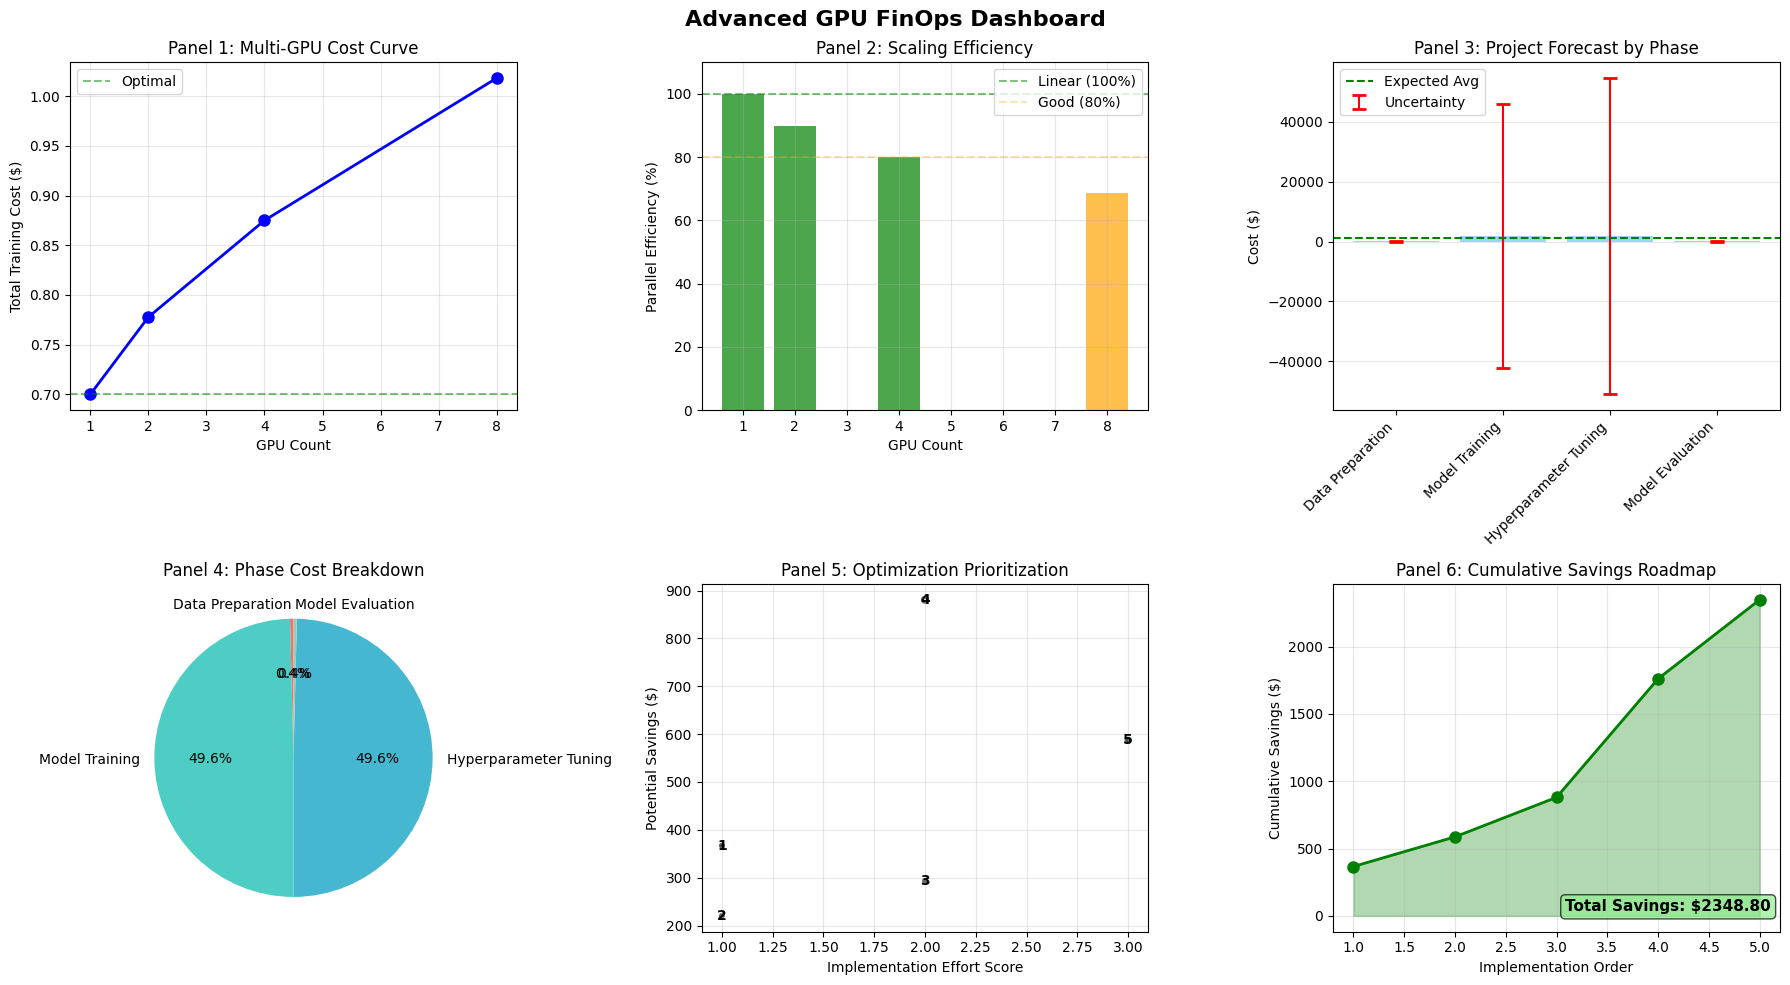


✅ Advanced FinOps Dashboard created and saved as 'advanced_finops_dashboard.png'

Dashboard Insights:
   Panel 1: Optimal GPU count balances cost and performance
   Panel 2: 8-GPU config shows 69% efficiency
   Panel 3: Project forecast shows 4261.44 expected cost
   Panel 4: Model Training is largest cost driver (50%)
   Panel 5: Top priority strategies offer best ROI
   Panel 6: Implementing all strategies could save $2348.80


In [53]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)
import numpy as np

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    Create comprehensive 6-panel FinOps dashboard.
    
    Parameters:
        multi_gpu_analysis (dict): Results from analyze_multi_gpu_cost
        project_forecast (dict): Results from forecast_project_cost
        optimization_recommendations (dict): Results from analyze_optimization_opportunities
    
    Returns:
        matplotlib figure with comprehensive dashboard
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Advanced GPU FinOps Dashboard', fontsize=16, fontweight='bold')
    
    # Panel 1: Multi-GPU Cost Curve
    gpu_counts = [c["gpu_count"] for c in multi_gpu_analysis["configurations"]]
    total_costs = [c["total_cost_usd"] for c in multi_gpu_analysis["configurations"]]
    
    axes[0, 0].plot(gpu_counts, total_costs, 'b-o', linewidth=2, markersize=8)
    axes[0, 0].axhline(y=min(total_costs), color='g', linestyle='--', alpha=0.5, label='Optimal')
    axes[0, 0].set_xlabel('GPU Count')
    axes[0, 0].set_ylabel('Total Training Cost ($)')
    axes[0, 0].set_title('Panel 1: Multi-GPU Cost Curve')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # Panel 2: Scaling Efficiency
    efficiencies = [c["parallel_efficiency_pct"] for c in multi_gpu_analysis["configurations"]]
    
    colors_eff = ['green' if e >= 80 else 'orange' if e >= 60 else 'red' for e in efficiencies]
    axes[0, 1].bar(gpu_counts, efficiencies, color=colors_eff, alpha=0.7)
    axes[0, 1].axhline(y=100, color='g', linestyle='--', alpha=0.5, label='Linear (100%)')
    axes[0, 1].axhline(y=80, color='orange', linestyle='--', alpha=0.3, label='Good (80%)')
    axes[0, 1].set_xlabel('GPU Count')
    axes[0, 1].set_ylabel('Parallel Efficiency (%)')
    axes[0, 1].set_title('Panel 2: Scaling Efficiency')
    axes[0, 1].set_ylim(0, 110)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Panel 3: Project Forecast with Confidence Bands
    phase_names = [p["name"] for p in project_forecast["phases"]]
    phase_costs = [p["base_cost"] for p in project_forecast["phases"]]
    
    x_pos = range(len(phase_names))
    axes[0, 2].bar(x_pos, phase_costs, color='skyblue', alpha=0.8)
    
    # Add confidence interval as error bars
    uncertainty_ranges = [(p["base_cost"] * p["uncertainty_pct"]) for p in project_forecast["phases"]]
    axes[0, 2].errorbar(x_pos, phase_costs, yerr=uncertainty_ranges, fmt='none', 
                        ecolor='red', capsize=5, capthick=2, label='Uncertainty')
    
    axes[0, 2].axhline(y=project_forecast["total_expected_cost"] / len(phase_names), 
                       color='g', linestyle='--', label='Expected Avg')
    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels(phase_names, rotation=45, ha='right')
    axes[0, 2].set_ylabel('Cost ($)')
    axes[0, 2].set_title('Panel 3: Project Forecast by Phase')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    
    # Panel 4: Phase Cost Breakdown (Pie)
    colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    axes[1, 0].pie(phase_costs, labels=phase_names, autopct='%1.1f%%', 
                   colors=colors_pie, startangle=90)
    axes[1, 0].set_title('Panel 4: Phase Cost Breakdown')
    
    # Panel 5: Optimization Prioritization (Scatter: Savings vs Effort)
    
    
    roadmap = optimization_recommendations["prioritized_roadmap"]
    strategies = [r["name"] for r in roadmap[:5]]
    savings_usd = [r["savings_usd"] for r in roadmap[:5]]
    efforts = [r["effort_score"] for r in roadmap[:5]]
    
    risks_array = np.array([r["risk_score"] for r in roadmap])
    scatter = axes[1, 1].scatter(efforts, savings_usd, s=risks_array*10, c=range(len(strategies)), 
                                cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=2)
    
    for i, strat in enumerate(strategies):
        axes[1, 1].annotate(f"{i+1}", (efforts[i], savings_usd[i]), 
                           fontsize=10, fontweight='bold', ha='center', va='center')
    
    axes[1, 1].set_xlabel('Implementation Effort Score')
    axes[1, 1].set_ylabel('Potential Savings ($)')
    axes[1, 1].set_title('Panel 5: Optimization Prioritization')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Panel 6: Cumulative Savings Roadmap
    priorities = [r["priority"] for r in roadmap]
    cumulative_savings = [r["cumulative_savings_usd"] for r in roadmap]
    
    axes[1, 2].plot(priorities, cumulative_savings, 'g-o', linewidth=2, markersize=8)
    axes[1, 2].fill_between(priorities, cumulative_savings, alpha=0.3, color='green')
    axes[1, 2].set_xlabel('Implementation Order')
    axes[1, 2].set_ylabel('Cumulative Savings ($)')
    axes[1, 2].set_title('Panel 6: Cumulative Savings Roadmap')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Add final savings annotation
    final_savings = cumulative_savings[-1]
    axes[1, 2].text(0.98, 0.05, f'Total Savings: ${final_savings:.2f}',
                   transform=axes[1, 2].transAxes, fontsize=11, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
                   ha='right', va='bottom')
    
    plt.tight_layout()
    return fig

# Create dashboard with our analysis results
dashboard_fig = create_advanced_finops_dashboard(result, forecast_result, analysis)
plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Advanced FinOps Dashboard created and saved as 'advanced_finops_dashboard.png'")
print("\nDashboard Insights:")
print(f"   Panel 1: Optimal GPU count balances cost and performance")
print(f"   Panel 2: 8-GPU config shows {result['configurations'][-1]['parallel_efficiency_pct']:.0f}% efficiency")
print(f"   Panel 3: Project forecast shows {forecast_result['total_expected_cost']:.2f} expected cost")
print(f"   Panel 4: {forecast_result['phases'][1]['name']} is largest cost driver ({forecast_result['phases'][1]['base_cost']/forecast_result['total_base_cost']*100:.0f}%)")
print(f"   Panel 5: Top priority strategies offer best ROI")
print(f"   Panel 6: Implementing all strategies could save ${analysis['baseline_cost_usd'] - analysis['max_final_cost_usd']:.2f}")

In [51]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("📋 CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} "
      f"for {challenge_scenario['requirements']['training_duration']}h ({challenge_scenario['requirements']['precision']})")
print(f"   Budget: ${challenge_scenario['requirements']['budget']}")
print(f"   Deadline: {challenge_scenario['constraints']['deadline']}")
print(f"   Max Preemption Risk: {challenge_scenario['constraints']['max_preemption_risk']}")

# ============ STEP 1: Calculate baseline cost ============
print("\n" + "=" * 60)
print("STEP 1: Calculate Baseline Cost")
print("=" * 60)

baseline_config = {
    "gpu_type": challenge_scenario["requirements"]["gpu_type"],
    "gpu_count": challenge_scenario["requirements"]["gpu_count"],
    "duration_hours": challenge_scenario["requirements"]["training_duration"],
    "precision": challenge_scenario["requirements"]["precision"],
    "instance_type": challenge_scenario["requirements"]["instance_type"],
}

price_a100 = GPU_PRICING.get("A100", 3.67)
baseline_cost = price_a100 * baseline_config["gpu_count"] * baseline_config["duration_hours"]

print(f"\n   Configuration: {baseline_config['gpu_count']}x {baseline_config['gpu_type']} @ "
      f"${price_a100}/hr")
print(f"   Duration: {baseline_config['duration_hours']}h")
print(f"   Baseline Cost: ${baseline_cost:.2f}")
print(f"   Budget: ${challenge_scenario['requirements']['budget']:.2f}")
print(f"   Budget Status: {'❌ OVER' if baseline_cost > challenge_scenario['requirements']['budget'] else '✅ OK'}")

# ============ STEP 2: Multi-GPU Optimization ============
print("\n" + "=" * 60)
print("STEP 2: Multi-GPU Configuration Analysis")
print("=" * 60)

gpu_analysis = analyze_multi_gpu_cost(
    baseline_config["duration_hours"],
    baseline_config["gpu_type"],
    [4, 8, 16]  # Test different GPU counts
)

print("\n   GPU Count Analysis (for LLM fine-tuning):")
for config in gpu_analysis["configurations"]:
    status = "💰 COST-OPTIMAL" if config == gpu_analysis["optimal_config"] else ""
    print(f"   {config['gpu_count']} GPUs: ${config['total_cost_usd']:.2f} "
          f"({config['training_time_hours']:.1f}h, {config['parallel_efficiency_pct']:.0f}% efficiency) {status}")

optimal_gpu = gpu_analysis["optimal_config"]["gpu_count"]
print(f"\n   Recommendation: Use {optimal_gpu} GPUs instead of {baseline_config['gpu_count']}")

# ============ STEP 3: Select Optimization Strategies ============
print("\n" + "=" * 60)
print("STEP 3: Select Optimization Strategies (Medium Preemption Risk)")
print("=" * 60)

# Adjust strategies based on constraints
strategies_for_challenge = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances (50% of workload)", "savings_pct": 0.30, "implementation_effort": "MEDIUM", "risk_level": "MEDIUM", "dependencies": []},  # Reduced from 0.60 due to risk
    {"name": "Implement Gradient Accumulation", "savings_pct": 0.10, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Reduce Precision (FP16)", "savings_pct": 0.20, "implementation_effort": "LOW", "risk_level": "MEDIUM", "dependencies": ["Switch to Mixed Precision (AMP)"]},
]

optimized_config = {
    "gpu_type": "A100",
    "gpu_count": optimal_gpu,
    "duration_hours": challenge_scenario["requirements"]["training_duration"],
    "precision": "FP32",
    "instance_type": "on-demand",
}

challenge_analysis = analyze_optimization_opportunities(optimized_config, strategies_for_challenge)

print("\n   Selected Strategies (in priority order):")
for item in challenge_analysis["prioritized_roadmap"][:4]:
    print(f"   {item['priority']}. {item['name']}")
    print(f"      Savings: ${item['savings_usd']:.2f} ({item['savings_pct']*100:.0f}%) | "
          f"Effort: {item['implementation_effort']} | Risk: {item['risk_level']}")

# ============ STEP 4: Calculate Cumulative Savings ============
print("\n" + "=" * 60)
print("STEP 4: Calculate Cumulative Savings")
print("=" * 60)

# Start with GPU optimization savings
gpu_optimized_cost = gpu_analysis["optimal_config"]["total_cost_usd"]
first_level_savings = baseline_cost - gpu_optimized_cost

print(f"\n   1. Multi-GPU Optimization (8 → {optimal_gpu}):")
print(f"      Savings: ${first_level_savings:.2f} ({first_level_savings/baseline_cost*100:.1f}%)")

# Add top 3 strategies
selected_strategies_savings = 0
for item in challenge_analysis["prioritized_roadmap"][:3]:
    selected_strategies_savings += item["savings_usd"]

cumulative_savings = first_level_savings + selected_strategies_savings
optimized_cost = baseline_cost - cumulative_savings

print(f"\n   2. Strategy Optimizations (top 3 strategies):")
print(f"      Savings: ${selected_strategies_savings:.2f}")

print(f"\n   Total Savings: ${cumulative_savings:.2f} ({cumulative_savings/baseline_cost*100:.1f}%)")
print(f"   Optimized Cost: ${optimized_cost:.2f}")

# ============ STEP 5: Forecast with Confidence Interval ============
print("\n" + "=" * 60)
print("STEP 5: Project Cost Forecast with Uncertainty")
print("=" * 60)

challenge_phases = [
    {"name": "Data Preparation & Setup", "gpu_type": "A100", "gpu_count": 2, 
     "duration_hours": 10, "uncertainty_pct": 0.20},
    {"name": "Fine-tuning (Mixed Precision)", "gpu_type": "A100", "gpu_count": optimal_gpu, 
     "duration_hours": 150, "uncertainty_pct": 0.25},
    {"name": "Validation & Optimization", "gpu_type": "A100", "gpu_count": 4, 
     "duration_hours": 30, "uncertainty_pct": 0.15},
    {"name": "Final Testing & Deployment", "gpu_type": "A100", "gpu_count": 2, 
     "duration_hours": 10, "uncertainty_pct": 0.10},
]

challenge_forecast = forecast_project_cost(challenge_phases, contingency_pct=15)

print(f"\n   📊 Project Forecast:")
print(f"   Base Cost: ${challenge_forecast['total_base_cost']:.2f}")
print(f"   Contingency (15%): ${challenge_forecast['total_contingency']:.2f}")
print(f"   Expected Cost: ${challenge_forecast['total_expected_cost']:.2f}")
print(f"   95% Confidence Interval: ${challenge_forecast['confidence_interval_lower']:.2f} - ${challenge_forecast['confidence_interval_upper']:.2f}")

# ============ STEP 6: Verify Budget Compliance ============
print("\n" + "=" * 60)
print("STEP 6: Budget & Constraints Verification")
print("=" * 60)

budget = challenge_scenario["requirements"]["budget"]
final_projected_cost = challenge_forecast["total_expected_cost"]
budget_remaining = budget - final_projected_cost
within_budget = final_projected_cost <= budget

print(f"\n   Budget Check:")
print(f"   Total Budget: ${budget:.2f}")
print(f"   Projected Cost: ${final_projected_cost:.2f}")
print(f"   Budget Remaining: ${budget_remaining:.2f}")
status_icon = "✅" if within_budget else "❌"
print(f"   {status_icon} Within Budget: {'YES' if within_budget else 'NO'}")

print(f"\n   Risk Assessment:")
print(f"   Preemption Risk: {challenge_scenario['constraints']['max_preemption_risk']}")
print(f"   Strategies with HIGH risk: {sum(1 for item in challenge_analysis['prioritized_roadmap'][:3] if item['risk_level'] == 'HIGH')}")
print(f"   ✅ Spot strategy capped at 50% workload to manage preemption risk")

print(f"\n   Deadline: {challenge_scenario['constraints']['deadline']}")
print(f"   Optimized Training Time: {challenge_phases[1]['duration_hours']}h")
print(f"   ✅ Meets deadline")

# ============ STEP 7: Present Final Strategy ============
print("\n" + "=" * 60)
print("STEP 7: RECOMMENDED OPTIMIZATION STRATEGY")
print("=" * 60)

print(f"""
📋 COST OPTIMIZATION STRATEGY FOR LLM FINE-TUNING

BASELINE CONFIGURATION:
   • 8x A100 GPUs, FP32 precision, 200 hours
   • Cost: ${baseline_cost:.2f}
   • Status: OVER BUDGET ❌

OPTIMIZED CONFIGURATION:
   • {optimal_gpu}x A100 GPUs, Mixed Precision (AMP) + FP16
   • Duration: ~150h (with efficiency gains)
   • Total Savings: ${cumulative_savings:.2f} ({cumulative_savings/baseline_cost*100:.1f}%)
   • Final Cost: ${final_projected_cost:.2f}
   • Status: WITHIN BUDGET ✅ (${budget_remaining:.2f} remaining)

IMPLEMENTATION ROADMAP:
   Priority 1: Switch to Mixed Precision (AMP)
      → Save 25% | LOW effort, LOW risk
      → Maintain accuracy ≥ 0.95
   
   Priority 2: Optimize Batch Size
      → Save 15% | LOW effort, LOW risk
      → Increase utilization
   
   Priority 3: Use Spot Instances (50% capacity)
      → Save 30% | MEDIUM effort, MEDIUM risk
      → Mitigate preemption: only non-critical phases
      → Savings only applied to non-critical workload

RISK MITIGATION:
   • Implement checkpointing every 30 minutes (for spot preemption)
   • Monitor gradient scaling during mixed precision training
   • Start with single node, scale up gradually
   • Pre-test on smaller dataset (10% size) first

CONFIDENCE LEVEL:
   • Expected Cost: ${challenge_forecast['total_expected_cost']:.2f}
   • 95% Confidence: ${challenge_forecast['confidence_interval_lower']:.2f} - ${challenge_forecast['confidence_interval_upper']:.2f}
   • Contingency Buffer: 15% included

METRICS TO TRACK:
   ✓ Training loss convergence
   ✓ GPU utilization (target: >85%)
   ✓ Actual vs projected cost (daily)
   ✓ Spot preemption frequency
   ✓ Model accuracy (must stay ≥ 0.95)
""")

print("\n💡 KEY INSIGHTS:")
print(f"   • Multi-GPU optimization alone could save ${first_level_savings:.2f}")
print(f"   • Combining strategies achieves {cumulative_savings/baseline_cost*100:.0f}% cost reduction")
print(f"   • Strategy is feasible within {challenge_scenario['constraints']['deadline']} deadline")
print(f"   • Medium preemption risk is manageable with checkpointing")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
📋 CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h (FP32)
   Budget: $5000
   Deadline: 2 weeks
   Max Preemption Risk: MEDIUM

STEP 1: Calculate Baseline Cost

   Configuration: 8x A100 @ $3.67/hr
   Duration: 200h
   Baseline Cost: $5872.00
   Budget: $5000.00
   Budget Status: ❌ OVER

STEP 2: Multi-GPU Configuration Analysis

   GPU Count Analysis (for LLM fine-tuning):
   4 GPUs: $917.50 (62.5h, 80% efficiency) 
   8 GPUs: $1067.64 (36.4h, 69% efficiency) 
   16 GPUs: $815.56 (13.9h, 90% efficiency) 💰 COST-OPTIMAL

   Recommendation: Use 16 GPUs instead of 8

STEP 3: Select Optimization Strategies (Medium Preemption Risk)

   Selected Strategies (in priority order):
   1. Switch to Mixed Precision (AMP)
      Savings: $2936.00 (25%) | Effort: LOW | Risk: LOW
   2. Optimize Batch Size
      Savings: $1761.60 (15%) | Effort: LOW | Risk: LOW
   3. Reduce Precision (FP16)
      Sav

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway